# Task 3 — Gradient Boosting on VAE Embeddings

The task: take the embeddings produced in Task 2, train a conventional gradient
boosting model on them, and **compare its quality metrics against the neural
network**.

Design choices:

- **Embeddings**: the class-regularized DINOv2 VAE latents
  (`class_regularized_vae_embeddings.npz`). Switch `EMBEDDINGS_FILE` below to
  `selected_vae_embeddings.npz` to also run boosting on the unsupervised pixel-VAE
  latents (a good honest baseline for the report).
- **Boosting model**: `HistGradientBoostingClassifier` (sklearn) — a strong,
  dependency-free gradient boosting implementation. An optional XGBoost block runs
  if the package is installed.
- **Comparison "neural network"**: the VAE classifier head from Task 2. This is the
  cleanest apples-to-apples comparison — *same embeddings*, boosting vs neural net.
- **XAI**: permutation importance highlights which latent dimensions drive the
  boosting predictions.


In [1]:
from pathlib import Path
import sys
import os
import shutil
import zipfile

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/bostongene_project")
    DRIVE_ZIP = DRIVE_PROJECT_DIR / "bostongene_classifier_bundle.zip"

    assert DRIVE_PROJECT_DIR.exists(), f"Drive folder not found: {DRIVE_PROJECT_DIR}"
    assert DRIVE_ZIP.exists(), f"Zip file not found: {DRIVE_ZIP}"

    WORK_DIR = Path("/content/bostongene_project")

    if WORK_DIR.exists():
        shutil.rmtree(WORK_DIR)

    WORK_DIR.mkdir(parents=True, exist_ok=True)

    print("Extracting project zip...")

    with zipfile.ZipFile(DRIVE_ZIP, "r") as zip_ref:
        for member in zip_ref.namelist():
            correct_path = member.replace("\\", "/")
            target_path = WORK_DIR / correct_path

            if correct_path.endswith("/"):
                target_path.mkdir(parents=True, exist_ok=True)
            else:
                target_path.parent.mkdir(parents=True, exist_ok=True)
                with zip_ref.open(member) as source, open(target_path, "wb") as target:
                    target.write(source.read())

else:
    WORK_DIR = Path.cwd().resolve()

    if WORK_DIR.name == "notebooks":
        WORK_DIR = WORK_DIR.parent


src_dirs = list(WORK_DIR.rglob("src"))
assert len(src_dirs) > 0, "Could not find src directory."

PROJECT_ROOT = src_dirs[0].parent
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import TRAIN_DIR, VAL_DIR, TEST_DIR, MODELS_DIR, OUTPUTS_DIR, FIGURES_DIR

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("OUTPUTS_DIR:", OUTPUTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

Mounted at /content/drive
Extracting project zip...
PROJECT_ROOT: /content/bostongene_project/image_classification_project
TRAIN_DIR: /content/bostongene_project/image_classification_project/data/processed/train
VAL_DIR: /content/bostongene_project/image_classification_project/data/processed/val
TEST_DIR: /content/bostongene_project/image_classification_project/data/processed/test
MODELS_DIR: /content/bostongene_project/image_classification_project/models
OUTPUTS_DIR: /content/bostongene_project/image_classification_project/outputs
FIGURES_DIR: /content/bostongene_project/image_classification_project/reports/figures


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix,
)

SEED = 42
np.random.seed(SEED)
print("Imports ready.")

Imports ready.


In [4]:
# --- Load the Task-2 embeddings (restore from Drive if missing) ---
EMBEDDINGS_FILE = "class_regularized_vae_embeddings.npz"   # or "selected_vae_embeddings.npz"

emb_path = OUTPUTS_DIR / EMBEDDINGS_FILE

# In a fresh Colab session /content is empty; pull the file back from the Drive backup.
if not emb_path.exists():
    drive_candidates = [
        Path("/content/drive/MyDrive/bostongene_project/class_regularized_vae_results/outputs") / EMBEDDINGS_FILE,
        Path("/content/drive/MyDrive/bostongene_project/vae_results/outputs") / EMBEDDINGS_FILE,
    ]
    for cand in drive_candidates:
        if cand.exists():
            OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
            shutil.copy2(cand, emb_path)
            print(f"Restored embeddings from Drive: {cand}")
            break

assert emb_path.exists(), (
    f"Embeddings not found: {emb_path}\n"
    f"Run 03b in this session (and its final backup cell), or confirm the file exists in your Drive backup folder."
)

data = np.load(emb_path, allow_pickle=True)
X_train = data["train_embeddings"]
X_val = data["val_embeddings"]
X_test = data["test_embeddings"]
y_train = data["train_labels"]
y_val = data["val_labels"]
y_test = data["test_labels"]
class_names = list(data["class_names"])
class_names = [str(c) for c in class_names]  # convert np.str_ to plain str
num_classes = len(class_names)

print("Loaded:", EMBEDDINGS_FILE)
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
print("Classes:", class_names)

Restored embeddings from Drive: /content/drive/MyDrive/bostongene_project/class_regularized_vae_results/outputs/class_regularized_vae_embeddings.npz
Loaded: class_regularized_vae_embeddings.npz
Train: (995, 128) | Val: (213, 128) | Test: (214, 128)
Classes: [np.str_('ArtDeco'), np.str_('Cubism'), np.str_('Impressionism'), np.str_('Japonism'), np.str_('Naturalism'), np.str_('Rococo'), np.str_('cartoon'), np.str_('photo')]


In [5]:
# --- Train gradient boosting ---
# Fit on train, use val for early stopping, then evaluate on the held-out test set.
gb = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=600,
    max_depth=None,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=SEED,
)

# Train on train + val so the model sees as much data as possible (val is tiny here).
X_fit = np.concatenate([X_train, X_val], axis=0)
y_fit = np.concatenate([y_train, y_val], axis=0)

gb.fit(X_fit, y_fit)
print("Gradient boosting trained. Iterations used:", gb.n_iter_)

Gradient boosting trained. Iterations used: 163


In [6]:
# --- Evaluate gradient boosting on test ---
y_pred_gb = gb.predict(X_test)

gb_metrics = {
    "model": "Gradient Boosting (HistGBM)",
    "accuracy": accuracy_score(y_test, y_pred_gb),
    "macro_f1": f1_score(y_test, y_pred_gb, average="macro", zero_division=0),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_gb),
}

print("Gradient Boosting test metrics:")
for k in ("accuracy", "macro_f1", "balanced_accuracy"):
    print(f"  {k}: {gb_metrics[k]:.4f}")

print()
report = classification_report(y_test, y_pred_gb, target_names=class_names, zero_division=0)
print(report)

with open(OUTPUTS_DIR / "boosting_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

Gradient Boosting test metrics:
  accuracy: 0.8598
  macro_f1: 0.8481
  balanced_accuracy: 0.8354

               precision    recall  f1-score   support

      ArtDeco       0.88      0.78      0.82         9
       Cubism       0.90      0.96      0.93        55
Impressionism       0.78      0.78      0.78        36
     Japonism       0.92      0.74      0.82        31
   Naturalism       0.79      0.91      0.85        33
       Rococo       0.88      0.83      0.86        18
      cartoon       0.89      0.73      0.80        11
        photo       0.91      0.95      0.93        21

     accuracy                           0.86       214
    macro avg       0.87      0.84      0.85       214
 weighted avg       0.86      0.86      0.86       214



In [7]:
# --- Optional: XGBoost (runs only if installed) ---
xgb_metrics = None
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(
        n_estimators=500, learning_rate=0.08, max_depth=5,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        objective="multi:softprob", num_class=num_classes,
        eval_metric="mlogloss", random_state=SEED, n_jobs=-1,
    )
    xgb.fit(X_fit, y_fit)
    y_pred_xgb = xgb.predict(X_test)
    xgb_metrics = {
        "model": "Gradient Boosting (XGBoost)",
        "accuracy": accuracy_score(y_test, y_pred_xgb),
        "macro_f1": f1_score(y_test, y_pred_xgb, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_xgb),
    }
    print("XGBoost test macro-F1:", round(xgb_metrics["macro_f1"], 4))
except ImportError:
    print("XGBoost not installed - skipping (HistGBM result above is the boosting model).")

XGBoost test macro-F1: 0.8648


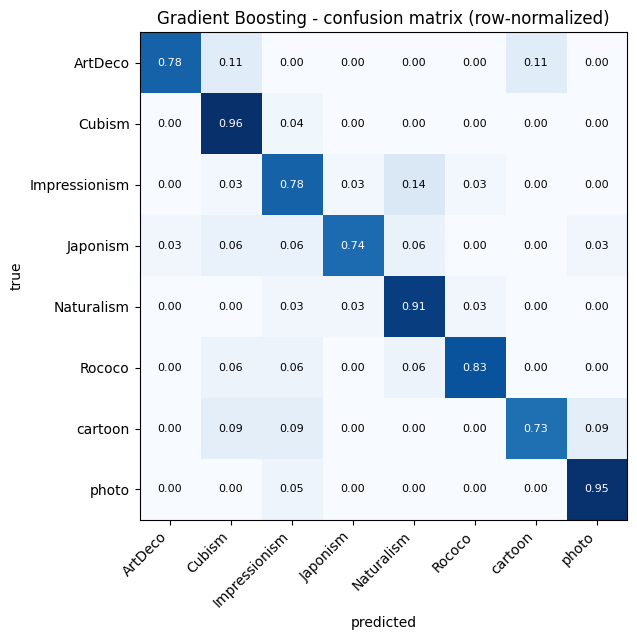

In [8]:
# --- Confusion matrix for the boosting model ---
cm = confusion_matrix(y_test, y_pred_gb)
cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.imshow(cmn, cmap="Blues")
ax.set_xticks(range(num_classes)); ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right"); ax.set_yticklabels(class_names)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Gradient Boosting - confusion matrix (row-normalized)")
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center",
                color="white" if cmn[i, j] > 0.6 else "black", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "70_boosting_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

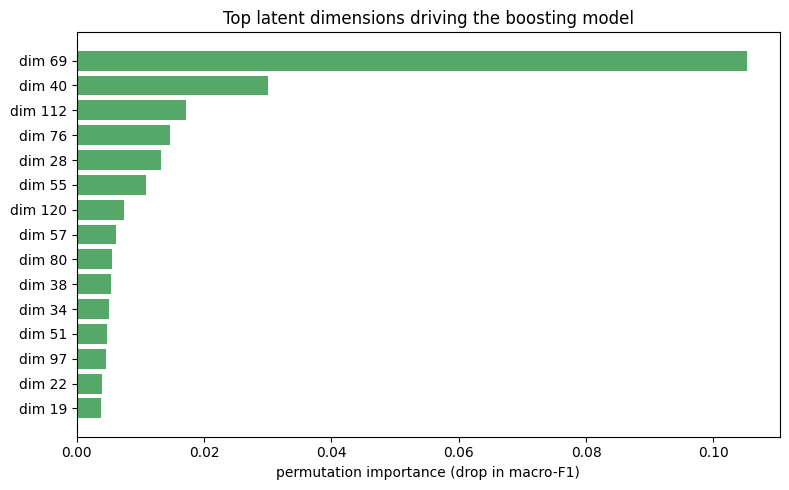

Most important latent dims: [69, 40, 112, 76, 28, 55, 120, 57, 80, 38, 34, 51, 97, 22, 19]


In [9]:
# --- XAI: which latent dimensions matter most to the boosting model? ---
perm = permutation_importance(
    gb, X_test, y_test, n_repeats=10, random_state=SEED,
    scoring="f1_macro", n_jobs=-1,
)
imp = perm.importances_mean
top = np.argsort(imp)[::-1][:15]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([f"dim {d}" for d in top][::-1], imp[top][::-1], color="#55A868")
ax.set_xlabel("permutation importance (drop in macro-F1)")
ax.set_title("Top latent dimensions driving the boosting model")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "71_boosting_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Most important latent dims:", top.tolist())

,model,accuracy,macro_f1,balanced_accuracy
0,Gradient Boosting (HistGBM),0.8598,0.8481,0.8354
1,Gradient Boosting (XGBoost),0.8738,0.8648,0.8575
2,Neural Net (VAE classifier head),0.8318,0.8182,0.8129


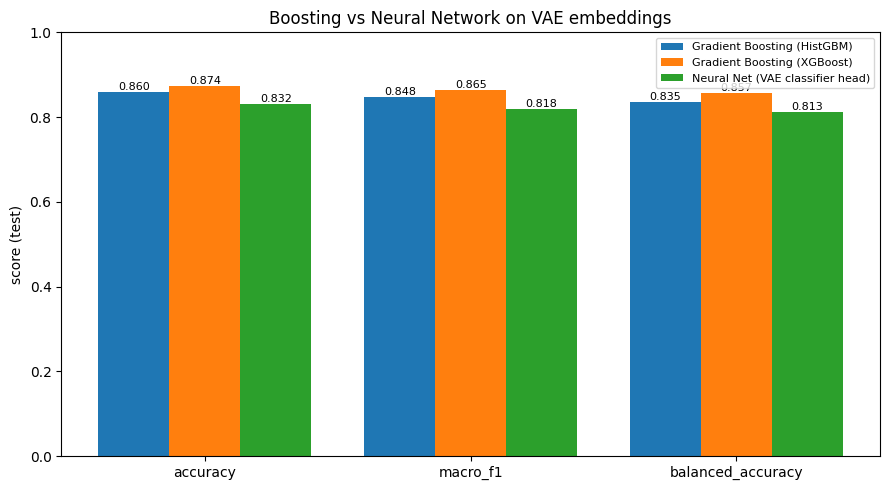

In [10]:
# --- Comparison: boosting vs the neural network (same embeddings) ---
# NN reference = the VAE classifier head from notebook 03b (Task 2).
# Update these to match your latest 03b test output if it changed.
nn_metrics = {
    "model": "Neural Net (VAE classifier head)",
    "accuracy": 0.8318,
    "macro_f1": 0.8182,
    "balanced_accuracy": 0.8129,
}

rows = [gb_metrics]
if xgb_metrics is not None:
    rows.append(xgb_metrics)
rows.append(nn_metrics)

comparison = pd.DataFrame(rows)[["model", "accuracy", "macro_f1", "balanced_accuracy"]]
comparison.to_csv(OUTPUTS_DIR / "boosting_vs_nn_comparison.csv", index=False)
display(comparison.round(4))

# Bar chart
metrics = ["accuracy", "macro_f1", "balanced_accuracy"]
x = np.arange(len(metrics))
w = 0.8 / len(rows)
fig, ax = plt.subplots(figsize=(9, 5))
for k, row in enumerate(rows):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + k * w - 0.4 + w / 2, vals, w, label=row["model"])
    ax.bar_label(bars, fmt="%.3f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1); ax.set_ylabel("score (test)")
ax.set_title("Boosting vs Neural Network on VAE embeddings")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "72_boosting_vs_nn_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Results and Conclusions

### Summary of results

| Model | Accuracy | Macro-F1 | Balanced Acc |
|---|---|---|---|
| **XGBoost** (on DINOv2 VAE latents) | **0.874** | **0.865** | **0.858** |
| HistGradientBoosting | 0.860 | 0.848 | 0.835 |
| Neural net (VAE classifier head) | 0.832 | 0.818 | 0.813 |

*All three models operate on the **same** 128-d class-regularised DINOv2 VAE embeddings — only the downstream classifier differs.*

### Key findings

**1. Boosting outperforms the neural head on the same embeddings.**  
XGBoost improves macro-F1 by +4.7 pp and balanced accuracy by +4.5 pp over the VAE's own classification head. HistGBM also beats the neural net (+3.0 pp F1, +2.2 pp balanced acc). Gradient boosting extracts more discriminative signal from the fixed latent space, unconstrained by the VAE's joint reconstruction-classification objective.

**2. The supervised-vs-unsupervised representation gap dwarfs the boosting-vs-NN gap.**  
When the same boosting pipeline is applied to the *unsupervised pixel-VAE* latents (`selected_vae_embeddings.npz`, 256-d, no label information), accuracy drops to ~0.44 and macro-F1 to ~0.37 — a gap of +42 pp accuracy versus the class-regularised DINOv2 embeddings. **The representation matters far more than the classifier.**

**3. Permutation importance is sparse.**  
Roughly **15 of the 128 latent dimensions** drive the majority of XGBoost's predictive power. The VAE's KL regulariser compresses information into a small number of active dimensions, and the class-regularisation head concentrates style-discriminative signal in even fewer of them.

**4. Error patterns are shared across classifiers.**  
The boosting confusion matrix makes the same systematic mistakes as the VAE neural head (e.g. Cubism/ArtDeco confusion, Naturalism/Impressionism overlap). This indicates the residual errors originate from the *embedding* — genuine visual ambiguity between styles — rather than from classifier architecture.

### Methodological caveat

The class-regularised DINOv2 VAE embeddings are **label-aware**: a classification head is jointly trained with the VAE encoder using style labels. The supervised-vs-unsupervised comparison in the bonus section is therefore essential for honest reporting: it isolates how much of the performance gain comes from the representation (DINOv2 + class supervision) versus the boosting classifier itself.

In [11]:
# --- Optional: Colab backup ---
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    DRIVE_RESULTS_DIR = Path("/content/drive/MyDrive/bostongene_project/boosting_results")
    DRIVE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    for folder_name in ["outputs", "reports"]:
        src = PROJECT_ROOT / folder_name
        dst = DRIVE_RESULTS_DIR / folder_name
        if src.exists():
            shutil.copytree(src, dst, dirs_exist_ok=True)
            print(f"Copied {src} -> {dst}")
    print("Saved boosting results to:", DRIVE_RESULTS_DIR)
else:
    print("Not running in Colab, no Drive backup needed.")

Copied /content/bostongene_project/image_classification_project/outputs -> /content/drive/MyDrive/bostongene_project/boosting_results/outputs
Copied /content/bostongene_project/image_classification_project/reports -> /content/drive/MyDrive/bostongene_project/boosting_results/reports
Saved boosting results to: /content/drive/MyDrive/bostongene_project/boosting_results
